In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# --- Load Your Merged Dataset ---
merged_file = 'merged_census_health_data.csv'

try:
    df = pd.read_csv(merged_file)
    print(f"Successfully loaded '{merged_file}'.")
    print(f"Data has {len(df)} rows (districts) and {len(df.columns)} columns.")
    print("\n--- Data Head ---")
    print(df.head())
    
except FileNotFoundError:
    print(f"ERROR: File not found. Make sure '{merged_file}' is in the correct directory.")

Successfully loaded 'merged_census_health_data.csv'.
Data has 482 rows (districts) and 17 columns.

--- Data Head ---
   District code  District Urban / rural No:of villages inhabited  \
0              1   Kupwara         Total                      353   
1              2    Badgam         Total                      462   
2              4    Kargil         Total                      125   
3              7    Kathua         Total                      496   
4              8  Baramula         Total                      509   

   No:of villages uninhabited  Number of towns Number of households  \
0                           9               10             1,13,929   
1                          12                9             1,03,363   
2                           2                1               18,338   
3                          16                6             1,19,583   
4                           9                7             1,52,635   

  Total population     Males   Females  

In [4]:
print("--- Data Columns and Types ---")
print(df.info())

print("\n--- Data Head (First 5 Rows) ---")
print(df.head())

--- Data Columns and Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 17 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   District code                       482 non-null    int64  
 1   District                            482 non-null    object 
 2   Urban / rural                       482 non-null    object 
 3   No:of villages inhabited            482 non-null    object 
 4   No:of villages uninhabited          482 non-null    int64  
 5   Number of towns                     482 non-null    int64  
 6   Number of households                482 non-null    object 
 7   Total population                    482 non-null    object 
 8   Males                               482 non-null    object 
 9   Females                             482 non-null    object 
 10  Area(In sq . km)                    482 non-null    float64
 11  Population per

In [5]:
# --- List of columns to clean (based on your df.info) ---
cols_to_clean = [
    'No:of villages inhabited',
    'Number of households',
    'Total population',
    'Males',
    'Females',
    'Population per sq . Km'
]

print(f"Cleaning {len(cols_to_clean)} columns...")

for col in cols_to_clean:
    if col in df.columns:
        # 1. Convert to string (in case there are already numbers)
        df[col] = df[col].astype(str)
        # 2. Remove commas
        df[col] = df[col].str.replace(',', '', regex=False)
        # 3. Convert to numeric, errors='coerce' turns bad data (like text) into NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')
    else:
        print(f"Warning: Column '{col}' not found in dataframe.")

# Fill any new NaNs created during conversion with 0 (or median if you prefer)
df[cols_to_clean] = df[cols_to_clean].fillna(0)

print("Data cleaning complete. Columns are now numeric.")

# --- Verify the changes ---
print("\n--- New Data Types ---")
print(df.info())

Cleaning 6 columns...
Data cleaning complete. Columns are now numeric.

--- New Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 17 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   District code                       482 non-null    int64  
 1   District                            482 non-null    object 
 2   Urban / rural                       482 non-null    object 
 3   No:of villages inhabited            482 non-null    int64  
 4   No:of villages uninhabited          482 non-null    int64  
 5   Number of towns                     482 non-null    int64  
 6   Number of households                482 non-null    int64  
 7   Total population                    482 non-null    int64  
 8   Males                               482 non-null    int64  
 9   Females                             482 non-null    int64  
 10  Area(In sq . km

In [7]:
df = df.drop(columns=['Urban / rural'])
print(df.head())

   District code  District  No:of villages inhabited  \
0              1   Kupwara                       353   
1              2    Badgam                       462   
2              4    Kargil                       125   
3              7    Kathua                       496   
4              8  Baramula                       509   

   No:of villages uninhabited  Number of towns  Number of households  \
0                           9               10                113929   
1                          12                9                103363   
2                           2                1                 18338   
3                          16                6                119583   
4                           9                7                152635   

   Total population   Males  Females  Area(In sq . km)  \
0            870354  474190   396164            2379.0   
1            753745  398041   355704            1361.0   
2            140802   77785    63017           14036.0  

In [8]:
POPULATION_COL = 'Total population'
MALES_COL = 'Males'
FEMALES_COL = 'Females'
HOUSEHOLDS_COL = 'Number of households'
DIS_HSPITL = 'District Hospital' 
PHC_COL = 'Number of  Primary Health Centres'
CHC_COL = 'Number of Community Health Centres'
SUB_CENTRES_COL = 'Number of Sub Centres'

In [9]:
df[POPULATION_COL] = df[POPULATION_COL].replace(0, 1)

In [18]:
# --- 3. Create Socio-Economic Features ---
# We create rates (percentages) because they are comparable between districts.
df['Percent_Female'] = df[FEMALES_COL] / df[POPULATION_COL]*100
df['Percent_Male'] = df[MALES_COL] / df[POPULATION_COL]*100
df['Avg_Household_Size'] = df[POPULATION_COL] / df[HOUSEHOLDS_COL].replace(0, 1)

In [15]:
# --- 4. Create Health Infrastructure Features (per 100,000 people) ---
# We'll create a "Total Facilities" column.
df['Total_Health_Facilities'] = df[SUB_CENTRES_COL] + df[PHC_COL] + df[CHC_COL]
df['Total_Hospitals'] = df['Sub Divisional Hospital'] + df['District Hospital']

In [27]:
 # create the rates per 100k people
df['Facilities_Per_100k'] = (df['Total_Health_Facilities'] / df[POPULATION_COL]) * 100000
df['Hospitals_Per_100k'] = (df['Total_Hospitals'] / df[POPULATION_COL]) * 100000 

In [28]:
df['Population_Density in sq km'] = df['Population per sq . Km']

In [33]:
print("Feature engineering complete.")
print("\n--- Data Head with New Features ---")
print(df[['District', 'Percent_Female', 'Percent_Male' , 'Facilities_Per_100k', 'Hospitals_Per_100k','Population_Density in sq km']].head())


Feature engineering complete.

--- Data Head with New Features ---
   District  Percent_Female  Percent_Male  Facilities_Per_100k  \
0   Kupwara       45.517571     54.482429            20.796136   
1    Badgam       47.191557     52.808443            22.288705   
2    Kargil       44.755756     55.244244            46.874334   
3    Kathua       47.097585     52.902415            26.929036   
4  Baramula       46.953144     53.046856            16.566819   

   Hospitals_Per_100k  Population_Density in sq km  
0            0.114896                          366  
1            0.132671                          554  
2            0.710217                           10  
3            0.162223                          246  
4            0.099203                          238  


In [35]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 25 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   District code                       482 non-null    int64  
 1   District                            482 non-null    object 
 2   No:of villages inhabited            482 non-null    int64  
 3   No:of villages uninhabited          482 non-null    int64  
 4   Number of towns                     482 non-null    int64  
 5   Number of households                482 non-null    int64  
 6   Total population                    482 non-null    int64  
 7   Males                               482 non-null    int64  
 8   Females                             482 non-null    int64  
 9   Area(In sq . km)                    482 non-null    float64
 10  Population per sq . Km              482 non-null    int64  
 11  Number of Sub Centres               482 non-n

In [36]:
df = df.drop(columns=['Population_Density'])

In [37]:
df.to_csv('engineered_vulnerability_data.csv', index=False)

In [38]:
from sklearn.preprocessing import StandardScaler
# This list should contain the new columns you just created.
# Add or remove any features you want to test.
vulnerability_features = [
    'Percent_Female',
    'Percent_Male',
    'Avg_Household_Size',
    'Facilities_Per_100k',
    'Hospitals_Per_100k',
    'Population_Density in sq km' 
]

In [39]:
# Create a new dataframe with just these features
# We'll also keep 'District' for labeling later
df_features = df[['District'] + vulnerability_features].copy()

# Handle any potential errors if a feature wasn't created
# or if it contains NaN/Inf values from the calculation
df_features = df_features.replace([np.inf, -np.inf], np.nan).dropna()

print(f"Features selected. Using {len(df_features)} complete rows.")

Features selected. Using 482 complete rows.


In [41]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   District                     482 non-null    object 
 1   Percent_Female               482 non-null    float64
 2   Percent_Male                 482 non-null    float64
 3   Avg_Household_Size           482 non-null    float64
 4   Facilities_Per_100k          482 non-null    float64
 5   Hospitals_Per_100k           482 non-null    float64
 6   Population_Density in sq km  482 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 26.5+ KB


In [42]:
# --- 2. Scale the features ---
# We only scale the numeric features, not the 'District' column
features_to_scale = df_features[vulnerability_features]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_to_scale)
print("Features scaled successfully.")
print("\n--- Scaled Features (Head) ---")
print(features_scaled[:5])

Features scaled successfully.

--- Scaled Features (Head) ---
[[-1.86779013  1.86779013  3.78863158  0.18126965 -0.21768859 -0.19247149]
 [-0.84631878  0.84631878  3.29313872  0.28696643 -0.19080131 -0.1266574 ]
 [-2.33265182  2.33265182  3.84387402  2.02800573  0.68281743 -0.31709817]
 [-0.90366049  0.90366049  0.24317255  0.61557293 -0.14609945 -0.23448049]
 [-0.99179923  0.99179923  2.31141558 -0.11823077 -0.24142682 -0.23728109]]


In [44]:
# --- Find Optimal Number of Clusters (K) using the Elbow Method ---
# We assume your scaled data from the previous cell is named 'features_scaled'

inertia = []
K_range = range(1, 11) # Test K from 1 to 10

for k in K_range:
    # n_init=10 is the default and silences a future warning
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)

Look for the 'bend' in the graph (e.g., K=3, 4, or 5). This is your optimal K.


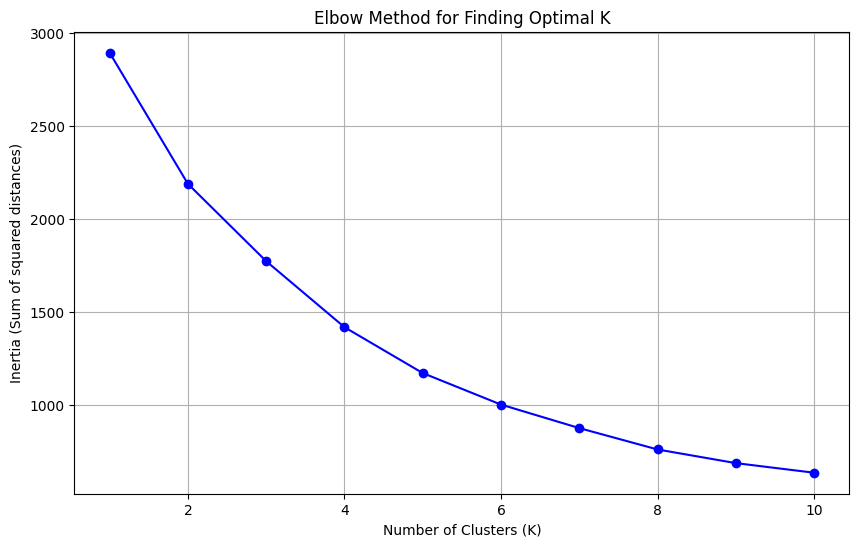

In [46]:
# --- Plot the Elbow Graph ---
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bo-') 
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of squared distances)')
plt.title('Elbow Method for Finding Optimal K')
plt.grid(True)
plt.savefig('elbow_plot.png')
print("Look for the 'bend' in the graph (e.g., K=3, 4, or 5). This is your optimal K.")

In [48]:
# --- Run K-Means with Your Chosen K ---
OPTIMAL_K = 4 
print(f"Running K-Means with K = {OPTIMAL_K}...")
# 1. Initialize and fit the model
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans.fit(features_scaled)
# 2. Get the cluster labels for each district
cluster_labels = kmeans.labels_

Running K-Means with K = 4...


In [49]:
# 3. Add the cluster labels back to your main dataframe
df['Vulnerability_Cluster'] = cluster_labels
print("K-Means complete. Cluster labels assigned to each district.")
print("\n--- Data Head with Cluster Labels ---")
print(df[['District', 'Vulnerability_Cluster']].head())

K-Means complete. Cluster labels assigned to each district.

--- Data Head with Cluster Labels ---
   District  Vulnerability_Cluster
0   Kupwara                      1
1    Badgam                      1
2    Kargil                      1
3    Kathua                      1
4  Baramula                      1


In [50]:
# --- Analyze the Cluster Profiles ---
# We'll group by the cluster and see the average value of our features
# We assume 'vulnerability_features' is the list from Cell 5

cluster_profile = df.groupby('Vulnerability_Cluster')[vulnerability_features].mean()

print("\n--- Cluster Profile Analysis (Mean Values) ---")
print(cluster_profile)

print("\n--- How to Read This ---")
print("Look for high/low values to name your clusters. For example:")
print("- A cluster with LOW 'Facilities_Per_100k' and HIGH 'Population_Density' is 'High Risk / Low Resources'.")
print("- A cluster with HIGH 'Facilities_Per_100k' and LOW 'Population_Density' is 'Low Risk / High Resources'.")


--- Cluster Profile Analysis (Mean Values) ---
                       Percent_Female  Percent_Male  Avg_Household_Size  \
Vulnerability_Cluster                                                     
0                           49.726266     50.273734            4.616398   
1                           47.437180     52.562820            5.400269   
2                           46.698644     53.301356            4.757491   
3                           44.852574     55.147426            4.100410   

                       Facilities_Per_100k  Hospitals_Per_100k  \
Vulnerability_Cluster                                            
0                                23.157680            0.273352   
1                                13.792062            0.190181   
2                                 1.190132            0.226395   
3                                 0.000000           12.493753   

                       Population_Density in sq km  
Vulnerability_Cluster                              

In [51]:
# --- Save the Final Dataframe ---
output_file = 'final_district_vulnerability_with_clusters.csv'
df.to_csv(output_file, index=False)

print(f"\nSuccessfully saved final data with cluster labels to: {output_file}")
print("This file is now ready to be used as input for your case prediction model (Objective 2).")


Successfully saved final data with cluster labels to: final_district_vulnerability_with_clusters.csv
This file is now ready to be used as input for your case prediction model (Objective 2).


In [52]:
df.head()

,District code,District,No:of villages inhabited,No:of villages uninhabited,Number of towns,Number of households,Total population,Males,Females,Area(In sq . km),...,District Hospital,Percent_Female,Avg_Household_Size,Total_Health_Facilities,Total_Hospitals,Facilities_Per_100k,Hospitals_Per_100k,Percent_Male,Population_Density in sq km,Vulnerability_Cluster
0,1,Kupwara,353,9,10,113929,870354,474190,396164,2379.0,...,1,45.517571,7.639442,181,1,20.796136,0.114896,54.482429,366,1
1,2,Badgam,462,12,9,103363,753745,398041,355704,1361.0,...,1,47.191557,7.292213,168,1,22.288705,0.132671,52.808443,554,1
2,4,Kargil,125,2,1,18338,140802,77785,63017,14036.0,...,1,44.755756,7.678155,66,1,46.874334,0.710217,55.244244,10,1
3,7,Kathua,496,16,6,119583,616435,326109,290326,2502.0,...,1,47.097585,5.154872,166,1,26.929036,0.162223,52.902415,246,1
4,8,Baramula,509,9,7,152635,1008039,534733,473306,4243.0,...,1,46.953144,6.604245,167,1,16.566819,0.099203,53.046856,238,1


In [ ]:
# What does this cluster values mean :

# Cluster 0: "High Vulnerability / Low Infrastructure"

# Cluster 1: "Low Vulnerability / High Infrastructure"

# Cluster 2: "Highly Populated / Average Infrastructure"

# Cluster 3: "Anomaly / Special Purpose Zones"

In [53]:
import pandas as pd

# --- 1. Load your new file with the cluster labels ---
try:
    df_final = pd.read_csv('final_district_vulnerability_with_clusters.csv')
    print("Loaded final data with cluster labels.")
except FileNotFoundError:
    print("ERROR: 'final_district_vulnerability_with_clusters.csv' not found.")
    raise

Loaded final data with cluster labels.


In [58]:
# --- 2. Define the list of features you engineered ---
# This list must match the features you used for clustering
vulnerability_features = [
    'Percent_Female',
    'Percent_Male',
    'Avg_Household_Size',
    'Facilities_Per_100k',
    'Hospitals_Per_100k',
    'Population_Density in sq km' 
]

In [59]:
# --- 3. Run the Cluster Profile Analysis ---
# This groups by the cluster label and calculates the average of each feature
cluster_profile = df_final.groupby('Vulnerability_Cluster')[vulnerability_features].mean()

print("\n--- Cluster Profile Analysis (Mean Values) ---")
print(cluster_profile)

print("\n--- How to Read This Table ---")
print("Compare the values in each row (cluster) to the others:")
print(" - A cluster with a LOW 'Facilities_Per_100k' and LOW 'Hospitals_Per_100k' is a **High-Risk (Low-Resource)** area.")
print(" - A cluster with a HIGH 'Facilities_Per_100k' and HIGH 'Population_Density' is a **Well-Resourced Urban** area.")
print(" - A cluster with HIGH 'Population_Density in sq km' but LOW 'Facilities_Per_100k' is a **High-Risk (Dense, Underserved)** area.")


--- Cluster Profile Analysis (Mean Values) ---
                       Percent_Female  Percent_Male  Avg_Household_Size  \
Vulnerability_Cluster                                                     
0                           49.726266     50.273734            4.616398   
1                           47.437180     52.562820            5.400269   
2                           46.698644     53.301356            4.757491   
3                           44.852574     55.147426            4.100410   

                       Facilities_Per_100k  Hospitals_Per_100k  \
Vulnerability_Cluster                                            
0                                23.157680            0.273352   
1                                13.792062            0.190181   
2                                 1.190132            0.226395   
3                                 0.000000           12.493753   

                       Population_Density in sq km  
Vulnerability_Cluster                              

C:\Users\Aathira baskaran\AppData\Local\Temp\ipykernel_32924\1124027864.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Plot 1 saved: 'top_10_most_vulnerable_districts.png'


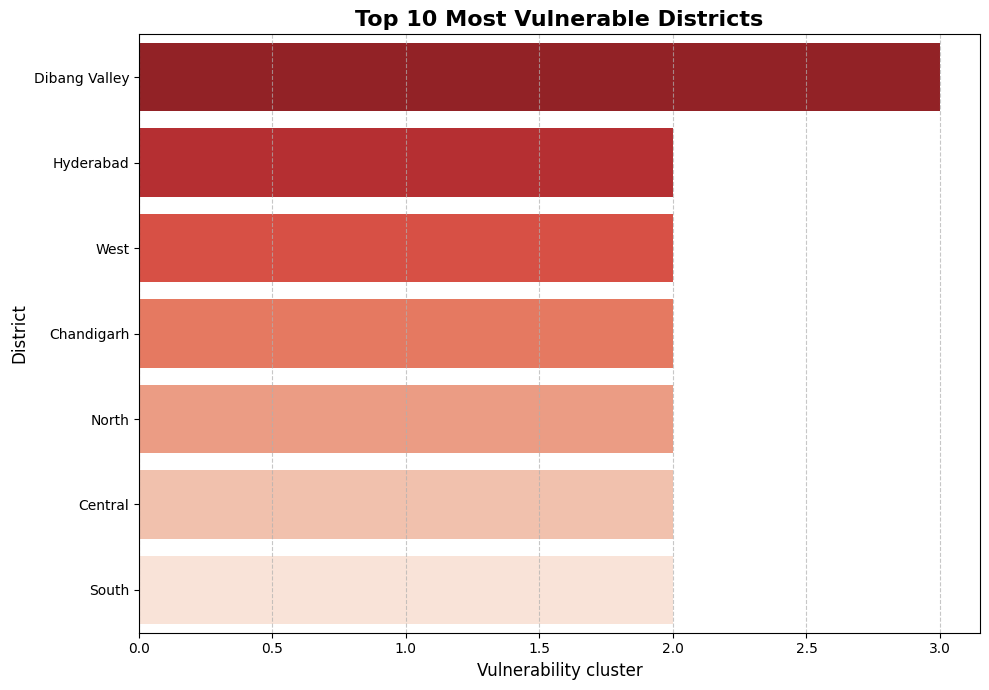

In [66]:
# Plot 1 - Top 10 Most Vulnerable Districts ---
import seaborn as sns
df_most_vulnerable = df_final.sort_values(by='Vulnerability_Cluster', ascending=False).head(10)

plt.figure(figsize=(10, 7))
sns.barplot(
    x='Vulnerability_Cluster', 
    y='District',
    data=df_most_vulnerable,
    palette='Reds_r'
)
plt.title('Top 10 Most Vulnerable Districts', fontsize=16, fontweight='bold')
plt.xlabel('Vulnerability cluster', fontsize=12)
plt.ylabel('District', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('top_10_most_vulnerable_districts.png')
print("Plot 1 saved: 'top_10_most_vulnerable_districts.png'")

C:\Users\Aathira baskaran\AppData\Local\Temp\ipykernel_32924\2333983256.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Plot 2 saved: 'top_10_least_vulnerable_districts_cluster_1.png'


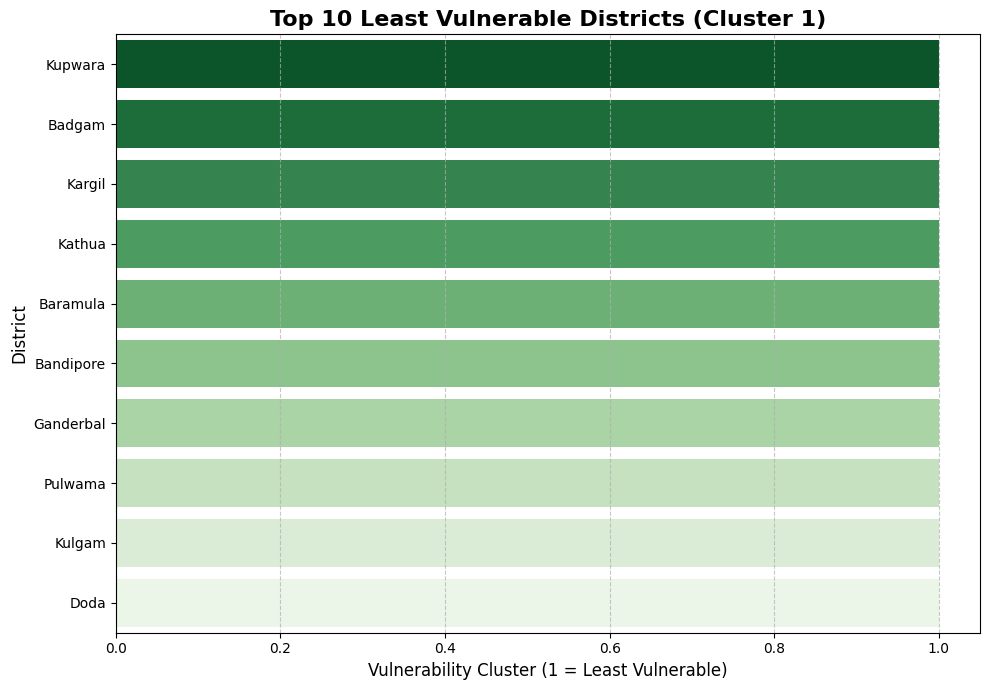

In [73]:
# --- 3. Plot 2 - Top 10 Least Vulnerable Districts (Cluster 1) ---

# Filter rows where Vulnerability_Cluster = 1
df_least_vulnerable_cluster = df_final[df_final['Vulnerability_Cluster'] == 1]

# Select Top 10 districts (you can sort by another column if needed)
df_plot_least_vulnerable = df_least_vulnerable_cluster.head(10)

plt.figure(figsize=(10, 7))
sns.barplot(
    x='Vulnerability_Cluster',
    y='District',
    data=df_plot_least_vulnerable,
    palette='Greens_r'
)

plt.title('Top 10 Least Vulnerable Districts (Cluster 1)', fontsize=16, fontweight='bold')
plt.xlabel('Vulnerability Cluster (1 = Least Vulnerable)', fontsize=12)
plt.ylabel('District', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('top_10_least_vulnerable_districts_cluster_1.png')

print("Plot 2 saved: 'top_10_least_vulnerable_districts_cluster_1.png'")


C:\Users\Aathira baskaran\AppData\Local\Temp\ipykernel_32924\1049180810.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Plot 3 saved: 'cluster_distribution.png'


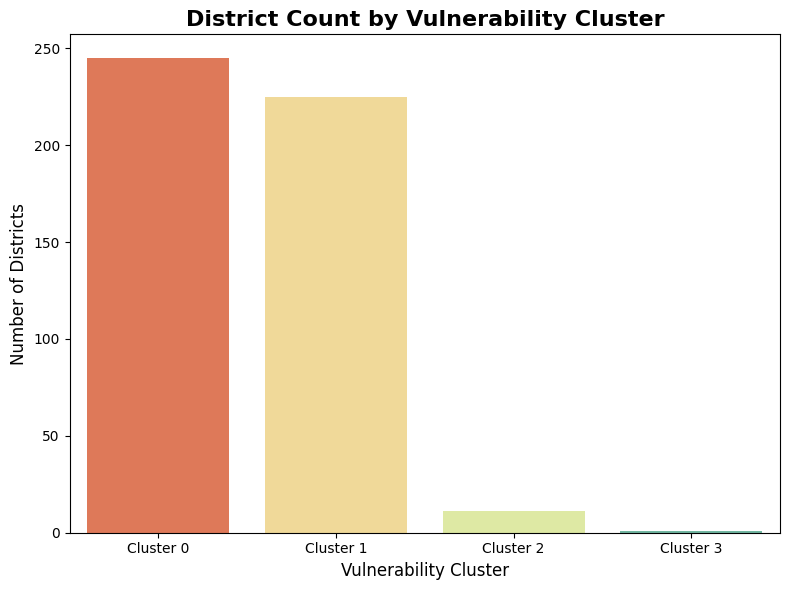

In [75]:
# --- Cell 5: Plot 3 - Distribution of Vulnerability Clusters ---
cluster_counts = df_final['Vulnerability_Cluster'].value_counts().sort_index()
cluster_names = [f"Cluster {i}" for i in cluster_counts.index]

plt.figure(figsize=(8, 6))
sns.barplot(
    x=cluster_names,
    y=cluster_counts.values,
    palette='Spectral'
)
plt.title('District Count by Vulnerability Cluster', fontsize=16, fontweight='bold')
plt.xlabel('Vulnerability Cluster', fontsize=12)
plt.ylabel('Number of Districts', fontsize=12)
plt.tight_layout()
plt.savefig('cluster_distribution.png')
print("Plot 3 saved: 'cluster_distribution.png'")

C:\Users\Aathira baskaran\AppData\Local\Temp\ipykernel_32924\4050707445.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Plot 1 saved: 'top_10_high_population_density.png'


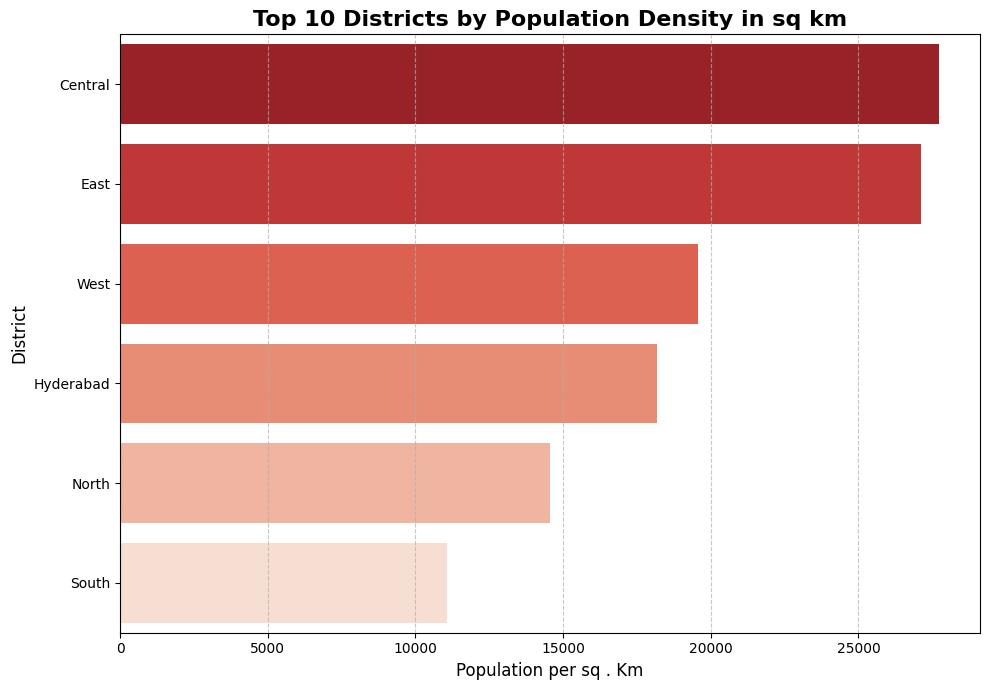

In [77]:
# --- 2. Plot 1: Districts with High 'Population_Density' ---
# Sort by Population_Density (descending) and take the top 10
df_high_density = df.sort_values(by='Population_Density in sq km', ascending=False).head(10)

plt.figure(figsize=(10, 7))
sns.barplot(
    x='Population_Density in sq km',
    y='District',
    data=df_high_density,
    palette='Reds_r'
)
plt.title('Top 10 Districts by Population Density in sq km', fontsize=16, fontweight='bold')
plt.xlabel('Population per sq . Km', fontsize=12)
plt.ylabel('District', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('top_10_high_population_density.png')
print("Plot 1 saved: 'top_10_high_population_density.png'")

C:\Users\Aathira baskaran\AppData\Local\Temp\ipykernel_32924\35887862.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Plot 2 (new) saved: 'top_10_people_per_facility.png'


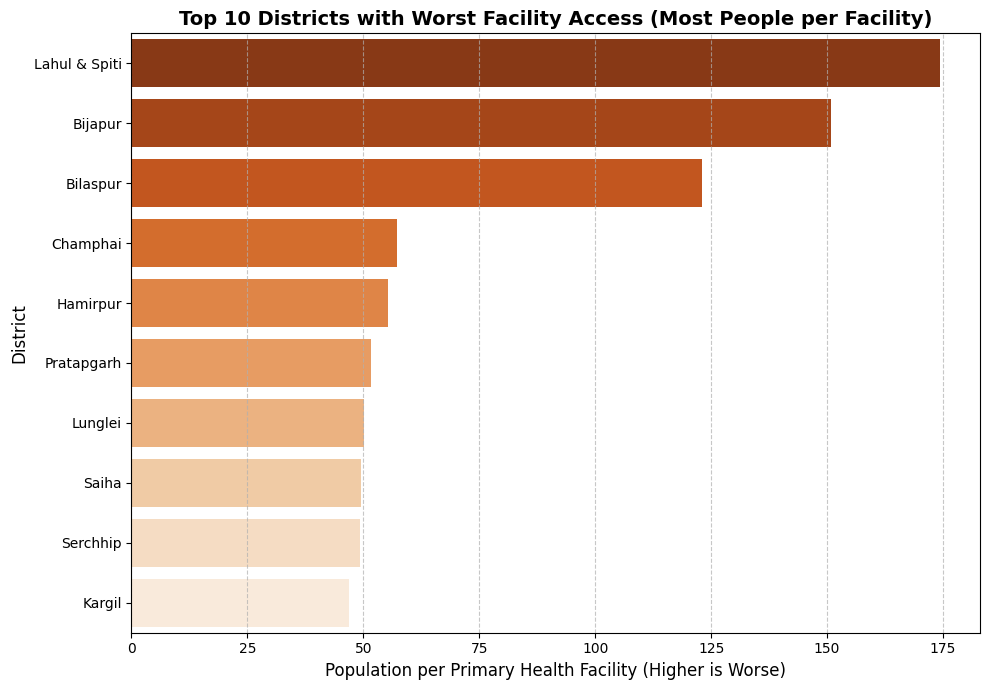

In [85]:
# --- 3. Plot 2: Districts with Worst "People_Per_Facility" ---
# Sort by People_Per_Facility (descending, higher is worse) and take top 10
df_low_facilities = df.sort_values(by='Facilities_Per_100k', ascending=False).head(10)

plt.figure(figsize=(10, 7))
sns.barplot(
    x='Facilities_Per_100k',
    y='District',
    data=df_low_facilities,
    palette='Oranges_r'
)
plt.title('Top 10 Districts with Worst Facility Access (Most People per Facility)', fontsize=14, fontweight='bold')
plt.xlabel('Population per Primary Health Facility (Higher is Worse)', fontsize=12)
plt.ylabel('District', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('top_10_people_per_facility.png')
print("Plot 2 (new) saved: 'top_10_people_per_facility.png'")

C:\Users\Aathira baskaran\AppData\Local\Temp\ipykernel_32924\2223616662.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Plot 3 (new) saved: 'top_10_people_per_hospital.png'


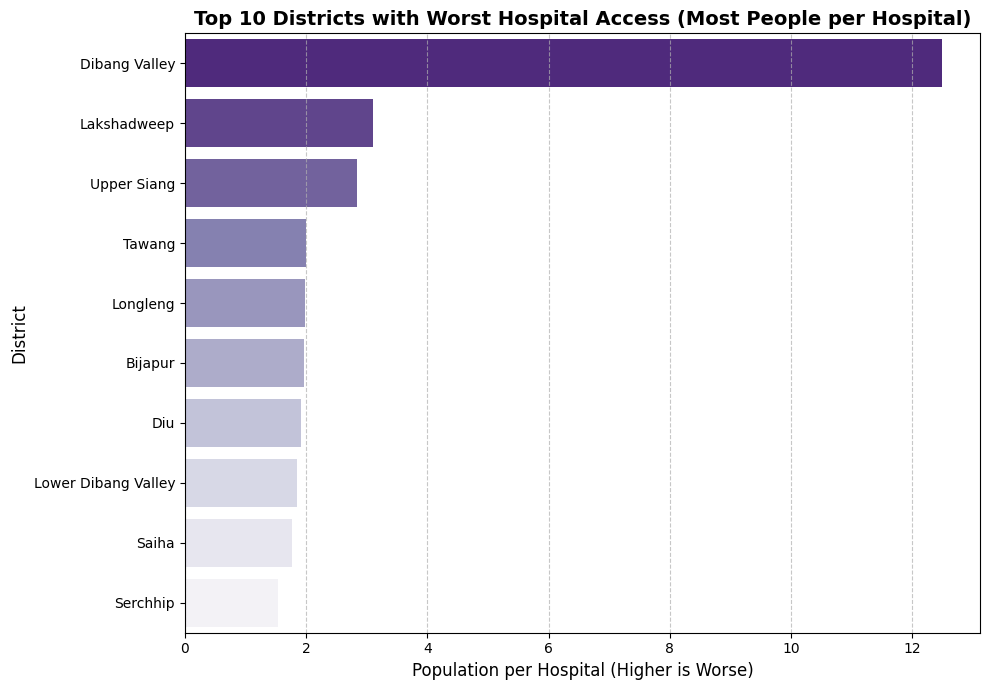

In [84]:
df_low_hospitals = df.sort_values(by='Hospitals_Per_100k', ascending=False).head(10)

plt.figure(figsize=(10, 7))
sns.barplot(
    x='Hospitals_Per_100k',
    y='District',
    data=df_low_hospitals,
    palette='Purples_r'
)
plt.title('Top 10 Districts with Worst Hospital Access (Most People per Hospital)', fontsize=14, fontweight='bold')
plt.xlabel('Population per Hospital (Higher is Worse)', fontsize=12)
plt.ylabel('District', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('top_10_people_per_hospital.png')
print("Plot 3 (new) saved: 'top_10_people_per_hospital.png'")